In [1]:
# CELL 1: IMPORT REQUIRED LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
import datetime

# For bonus (optional)
from xgboost import XGBRegressor
import lightgbm as lgb

warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(" Libraries imported successfully")
print(f"   Pandas version: {pd.__version__}")
print(f"   NumPy version: {np.__version__}")

 Libraries imported successfully
   Pandas version: 2.0.3
   NumPy version: 1.24.3


In [2]:
# CELL 2: LOAD AND EXPLORE DATASET


def load_sales_data():
    
    
    # IMPORTANT: Update this path to your dataset folder
    folder_path = r"D:\Elevvo_ML\data set of task 7"
    
    print(" Loading dataset files...")
    
    import os
    import glob
    
    # Check if folder exists
    if not os.path.exists(folder_path):
        print(f" Error: Folder not found at {folder_path}")
        return None, None
    
    # Show all files in the folder
    print(f"\n Files found in folder:")
    files = os.listdir(folder_path)
    for file in files:
        print(f"   - {file}")
    
    # Look for CSV files
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
    
    if len(csv_files) == 0:
        print(" No CSV files found in the folder")
        return None, None
    
    # Try to find train and test files
    train_df = None
    test_df = None
    
    for file in csv_files:
        file_name = os.path.basename(file).lower()
        if 'train' in file_name:
            print(f"\n Loading training data: {os.path.basename(file)}")
            train_df = pd.read_csv(file)
            print(f"   Train shape: {train_df.shape}")
        elif 'test' in file_name:
            print(f"\n Loading test data: {os.path.basename(file)}")
            test_df = pd.read_csv(file)
            print(f"   Test shape: {test_df.shape}")
    
    # If no train/test split found, load all CSV files
    if train_df is None and test_df is None and len(csv_files) > 0:
        print("\n No train/test split found. Loading first CSV file as main dataset:")
        main_file = csv_files[0]
        print(f"   Loading: {os.path.basename(main_file)}")
        main_df = pd.read_csv(main_file)
        print(f"   Main dataset shape: {main_df.shape}")
        return main_df, None
    
    return train_df, test_df

# Load the data
train_df, test_df = load_sales_data()

# Display information
print("\n" + "="*60)
print("DATASET LOADING SUMMARY")
print("="*60)

if train_df is not None:
    print(f"\n Training Set:")
    print(f"   Shape: {train_df.shape}")
    print(f"   Columns: {list(train_df.columns)}")
    print(f"\nFirst 5 rows of training data:")
    print(train_df.head())

if test_df is not None:
    print(f"\n Test Set:")
    print(f"   Shape: {test_df.shape}")
    print(f"   Columns: {list(test_df.columns)}")
    print(f"\nFirst 5 rows of test data:")
    print(test_df.head())

 Loading dataset files...

 Files found in folder:
   - features.csv
   - stores.csv
   - test.csv
   - train.csv

 Loading test data: test.csv
   Test shape: (115064, 4)

 Loading training data: train.csv
   Train shape: (421570, 5)

DATASET LOADING SUMMARY

 Training Set:
   Shape: (421570, 5)
   Columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']

First 5 rows of training data:
   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
3      1     1  2010-02-26      19403.54      False
4      1     1  2010-03-05      21827.90      False

 Test Set:
   Shape: (115064, 4)
   Columns: ['Store', 'Dept', 'Date', 'IsHoliday']

First 5 rows of test data:
   Store  Dept        Date  IsHoliday
0      1     1  2012-11-02      False
1      1     1  2012-11-09      False
2      1     1  2012-11-16      False
3      1     1  2012-11-23 

In [6]:
# CELL 3: EXPLORATORY DATA ANALYSIS

def explore_data(df, dataset_name="Training"):
    """
    Perform exploratory data analysis on the dataset
    """
    if df is None:
        print(f" No {dataset_name} data to explore")
        return
    
    print(f"\n" + "="*60)
    print(f"EXPLORING {dataset_name.upper()} DATA")
    print("="*60)
    
    # Basic information
    print(f"\n Dataset Shape: {df.shape}")
    print(f"\n Column Names:")
    for col in df.columns:
        print(f"   - {col}")
    
    # Data types
    print(f"\n Data Types:")
    print(df.dtypes)
    
    # Missing values
    print(f"\n Missing Values:")
    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100
    missing_df = pd.DataFrame({
        'Missing Values': missing,
        'Percentage': missing_percent
    })
    print(missing_df[missing_df['Missing Values'] > 0] if any(missing > 0) else "No missing values found!")
    
    # Statistical summary
    print(f"\n Statistical Summary (Numerical Columns):")
    print(df.describe())
    
    # Identify potential date columns
    date_columns = []
    for col in df.columns:
        if 'date' in col.lower() or 'day' in col.lower() or 'week' in col.lower() or 'month' in col.lower() or 'year' in col.lower():
            date_columns.append(col)
    
    if date_columns:
        print(f"\n📅 Potential Date Columns: {date_columns}")
    
    # Identify potential target column (sales)
    target_candidates = []
    for col in df.columns:
        if 'sales' in col.lower() or 'revenue' in col.lower() or 'demand' in col.lower() or 'quantity' in col.lower():
            target_candidates.append(col)
    
    if target_candidates:
        print(f"\n Potential Target Columns: {target_candidates}")
    
    return date_columns, target_candidates

# Explore training data
if train_df is not None:
    date_cols, target_cols = explore_data(train_df, "Training")
    
    # If test data exists, explore it too
    if test_df is not None:
        explore_data(test_df, "Test")


EXPLORING TRAINING DATA

 Dataset Shape: (421570, 5)

 Column Names:
   - Store
   - Dept
   - Date
   - Weekly_Sales
   - IsHoliday

 Data Types:
Store             int64
Dept              int64
Date             object
Weekly_Sales    float64
IsHoliday          bool
dtype: object

 Missing Values:
No missing values found!

 Statistical Summary (Numerical Columns):
               Store           Dept   Weekly_Sales
count  421570.000000  421570.000000  421570.000000
mean       22.200546      44.260317   15981.258123
std        12.785297      30.492054   22711.183519
min         1.000000       1.000000   -4988.940000
25%        11.000000      18.000000    2079.650000
50%        22.000000      37.000000    7612.030000
75%        33.000000      74.000000   20205.852500
max        45.000000      99.000000  693099.360000

📅 Potential Date Columns: ['Date', 'Weekly_Sales', 'IsHoliday']

 Potential Target Columns: ['Weekly_Sales']

EXPLORING TEST DATA

 Dataset Shape: (115064, 4)

 Column Name


📝 Based on the data exploration, please identify:
   Possible date columns: ['Date', 'Weekly_Sales', 'IsHoliday']


   Possible target columns: ['Weekly_Sales']

📊 Visualizing data with target: Weekly_Sales


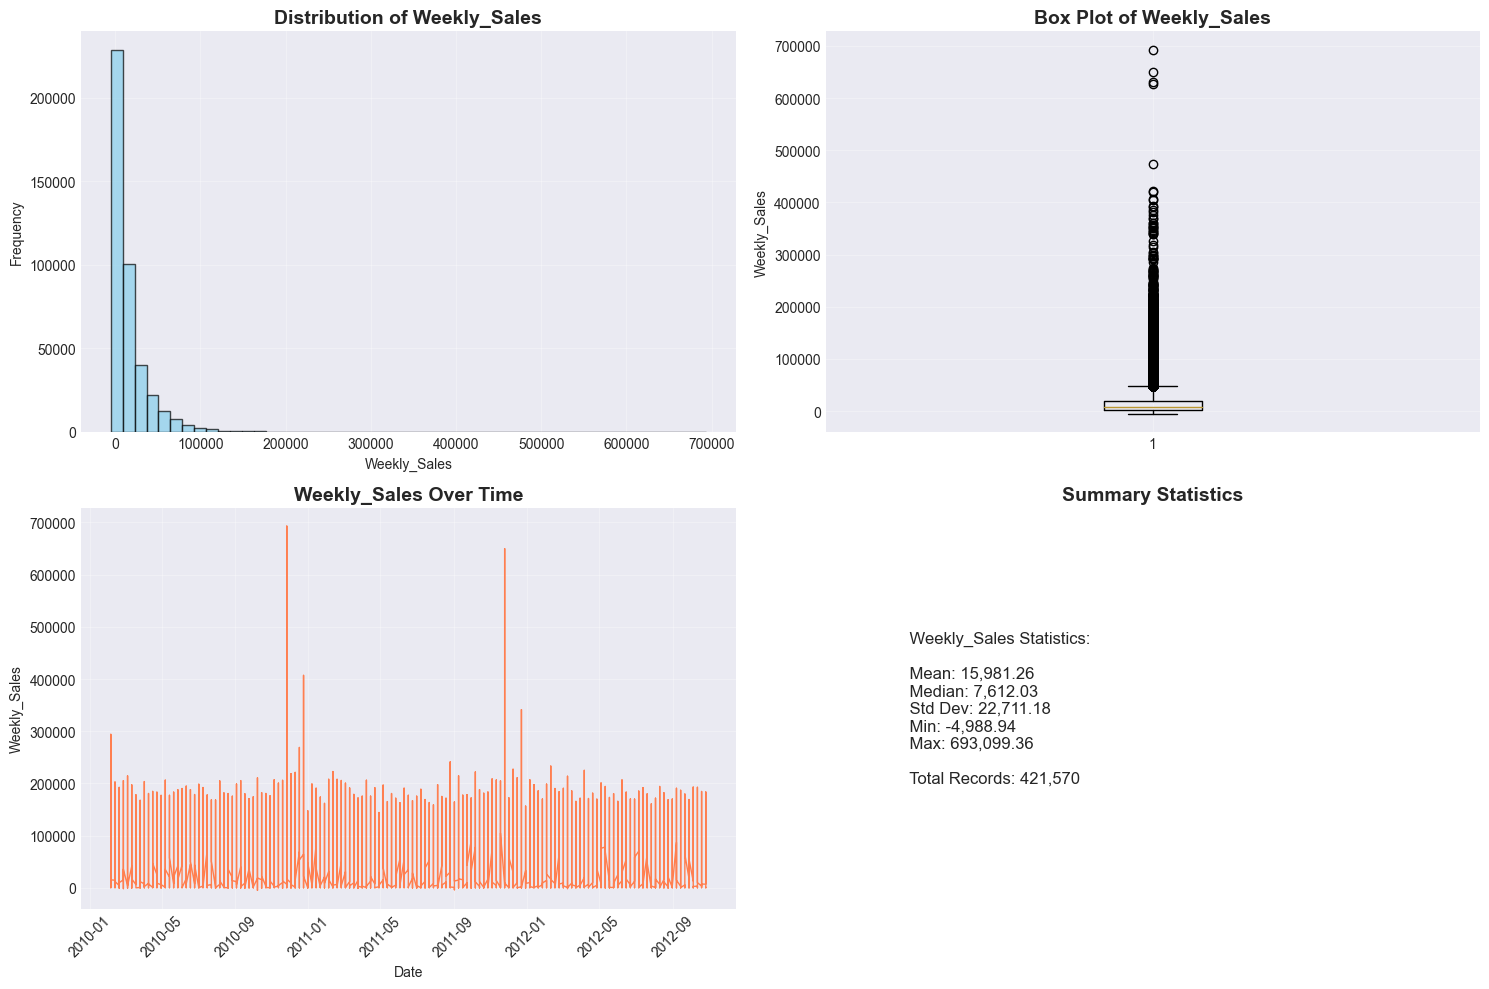

In [7]:
# CELL 4: VISUALIZE SALES DATA

def visualize_sales_data(df, date_col=None, target_col=None):
    """
    Create visualizations for sales data
    """
    if df is None:
        print(" No data to visualize")
        return
    
    # If no target column specified, try to find it
    if target_col is None:
        for col in df.columns:
            if 'sales' in col.lower() or 'revenue' in col.lower():
                target_col = col
                break
    
    if target_col is None:
        print(" Could not identify sales column")
        return
    
    print(f"\n📊 Visualizing data with target: {target_col}")
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Distribution of target variable
    axes[0, 0].hist(df[target_col].dropna(), bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    axes[0, 0].set_title(f'Distribution of {target_col}', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel(target_col)
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Box plot of target variable
    axes[0, 1].boxplot(df[target_col].dropna())
    axes[0, 1].set_title(f'Box Plot of {target_col}', fontsize=14, fontweight='bold')
    axes[0, 1].set_ylabel(target_col)
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Time series plot (if date column exists)
    if date_col and date_col in df.columns:
        # Convert to datetime
        df_sorted = df.copy()
        df_sorted[date_col] = pd.to_datetime(df_sorted[date_col])
        df_sorted = df_sorted.sort_values(date_col)
        
        axes[1, 0].plot(df_sorted[date_col], df_sorted[target_col], color='coral', linewidth=1)
        axes[1, 0].set_title(f'{target_col} Over Time', fontsize=14, fontweight='bold')
        axes[1, 0].set_xlabel('Date')
        axes[1, 0].set_ylabel(target_col)
        axes[1, 0].tick_params(axis='x', rotation=45)
        axes[1, 0].grid(True, alpha=0.3)
    else:
        axes[1, 0].text(0.5, 0.5, 'No date column available', 
                       horizontalalignment='center', fontsize=12)
        axes[1, 0].set_title('Time Series Plot', fontsize=14, fontweight='bold')
    
    # 4. Summary statistics as text
    axes[1, 1].axis('off')
    stats_text = f"""
    {target_col} Statistics:
    
    Mean: {df[target_col].mean():,.2f}
    Median: {df[target_col].median():,.2f}
    Std Dev: {df[target_col].std():,.2f}
    Min: {df[target_col].min():,.2f}
    Max: {df[target_col].max():,.2f}
    
    Total Records: {len(df):,}
    """
    axes[1, 1].text(0.1, 0.5, stats_text, fontsize=12, verticalalignment='center')
    axes[1, 1].set_title('Summary Statistics', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Ask user to confirm date and target columns
print("\n📝 Based on the data exploration, please identify:")

if 'date_cols' in locals() and date_cols:
    print(f"   Possible date columns: {date_cols}")
    selected_date = input("   Enter the date column name (or press Enter if none): ").strip()
    if selected_date == "":
        selected_date = None
else:
    selected_date = None
    print("   No date columns automatically detected")

if 'target_cols' in locals() and target_cols:
    print(f"   Possible target columns: {target_cols}")
    selected_target = input("   Enter the target (sales) column name: ").strip()
else:
    selected_target = input("   Enter the target (sales) column name: ").strip()

# Visualize the data
if train_df is not None and selected_target:
    visualize_sales_data(train_df, selected_date, selected_target)

In [9]:
# CELL 5: FEATURE ENGINEERING (UPDATED)

def create_time_features(df, date_column):
    """
    Create time-based features from date column
    """
    print("\n" + "="*60)
    print("FEATURE ENGINEERING")
    print("="*60)
    
    df_copy = df.copy()
    
    # Convert date column to datetime
    df_copy[date_column] = pd.to_datetime(df_copy[date_column])
    
    # Extract time features
    print("\n📅 Creating time-based features...")
    df_copy['Year'] = df_copy[date_column].dt.year
    df_copy['Month'] = df_copy[date_column].dt.month
    df_copy['Week'] = df_copy[date_column].dt.isocalendar().week
    df_copy['Day'] = df_copy[date_column].dt.day
    df_copy['DayOfWeek'] = df_copy[date_column].dt.dayofweek
    df_copy['Quarter'] = df_copy[date_column].dt.quarter
    df_copy['IsWeekend'] = (df_copy['DayOfWeek'] >= 5).astype(int)
    
    print("✅ Time features created:")
    print(f"   - Year, Month, Week, Day")
    print(f"   - DayOfWeek, Quarter, IsWeekend")
    
    return df_copy

def create_lag_features(df, target_col, lags=[1, 2, 3, 4], is_training=True):
    """
    Create lag features (previous weeks' sales)
    """
    print("\n📊 Creating lag features...")
    df_copy = df.copy()
    
    # Sort by date first
    if 'Date' in df_copy.columns:
        df_copy = df_copy.sort_values('Date')
    
    # Check if target column exists
    if target_col in df_copy.columns:
        for lag in lags:
            df_copy[f'Sales_Lag_{lag}'] = df_copy[target_col].shift(lag)
            print(f"   - Created Sales_Lag_{lag}")
        
        # Drop rows with NaN values from lag features (only for training)
        if is_training:
            initial_rows = len(df_copy)
            df_copy = df_copy.dropna()
            print(f"\n✅ Dropped {initial_rows - len(df_copy)} rows with NaN values from lag features")
    else:
        print(f"   ⚠️ Target column '{target_col}' not found. Skipping lag features for this dataset.")
    
    return df_copy

def create_rolling_features(df, target_col, windows=[4, 8, 12], is_training=True):
    """
    Create rolling average features
    """
    print("\n📈 Creating rolling average features...")
    df_copy = df.copy()
    
    # Check if target column exists
    if target_col in df_copy.columns:
        for window in windows:
            df_copy[f'Rolling_Mean_{window}'] = df_copy[target_col].rolling(window=window).mean()
            df_copy[f'Rolling_Std_{window}'] = df_copy[target_col].rolling(window=window).std()
            print(f"   - Created Rolling_Mean_{window} and Rolling_Std_{window}")
        
        # Drop rows with NaN values (only for training)
        if is_training:
            initial_rows = len(df_copy)
            df_copy = df_copy.dropna()
            print(f"\n✅ Dropped {initial_rows - len(df_copy)} rows with NaN values from rolling features")
    else:
        print(f"   ⚠️ Target column '{target_col}' not found. Skipping rolling features for this dataset.")
    
    return df_copy

# Apply feature engineering
if train_df is not None and selected_date and selected_target:
    print("\n" + "="*60)
    print("APPLYING FEATURE ENGINEERING TO TRAINING DATA")
    print("="*60)
    
    # Create time features
    train_processed = create_time_features(train_df, selected_date)
    
    # Sort by date
    train_processed = train_processed.sort_values(selected_date)
    
    # Create lag features (with training=True to drop NaN)
    train_processed = create_lag_features(train_processed, selected_target, is_training=True)
    
    # Create rolling features (with training=True to drop NaN)
    train_processed = create_rolling_features(train_processed, selected_target, is_training=True)
    
    print(f"\n✅ Final training data shape: {train_processed.shape}")
    print(f"   Columns: {list(train_processed.columns)}")
    
    # Show sample of new features
    print("\n🔍 Sample of new features:")
    new_features = [col for col in train_processed.columns if col not in train_df.columns]
    print(train_processed[new_features].head())
    
    # Apply same transformations to test data if available
    if test_df is not None:
        print("\n" + "="*60)
        print("APPLYING FEATURE ENGINEERING TO TEST DATA")
        print("="*60)
        
        test_processed = create_time_features(test_df, selected_date)
        test_processed = test_processed.sort_values(selected_date)
        
        # For test data, we create lag features WITHOUT dropping NaN
        # Because test data doesn't have the target column
        test_processed = create_lag_features(test_processed, selected_target, is_training=False)
        test_processed = create_rolling_features(test_processed, selected_target, is_training=False)
        
        print(f"\n✅ Final test data shape: {test_processed.shape}")
        print(f"   Columns: {list(test_processed.columns)}")
        
        # Show test data sample
        print("\n🔍 Test data sample:")
        print(test_processed.head())


APPLYING FEATURE ENGINEERING TO TRAINING DATA

FEATURE ENGINEERING

📅 Creating time-based features...
✅ Time features created:
   - Year, Month, Week, Day
   - DayOfWeek, Quarter, IsWeekend

📊 Creating lag features...
   - Created Sales_Lag_1
   - Created Sales_Lag_2
   - Created Sales_Lag_3
   - Created Sales_Lag_4

✅ Dropped 4 rows with NaN values from lag features

📈 Creating rolling average features...
   - Created Rolling_Mean_4 and Rolling_Std_4
   - Created Rolling_Mean_8 and Rolling_Std_8
   - Created Rolling_Mean_12 and Rolling_Std_12

✅ Dropped 11 rows with NaN values from rolling features

✅ Final training data shape: (421555, 22)
   Columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Year', 'Month', 'Week', 'Day', 'DayOfWeek', 'Quarter', 'IsWeekend', 'Sales_Lag_1', 'Sales_Lag_2', 'Sales_Lag_3', 'Sales_Lag_4', 'Rolling_Mean_4', 'Rolling_Std_4', 'Rolling_Mean_8', 'Rolling_Std_8', 'Rolling_Mean_12', 'Rolling_Std_12']

🔍 Sample of new features:
       Year  Month 

In [12]:
# CELL 6: PREPROCESSING AND SCALING 

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

def prepare_features(df, target_col, exclude_cols=None, is_training=True):
    """
    Prepare features for modeling
    
    Parameters:
    - df: dataframe
    - target_col: name of target column
    - exclude_cols: columns to exclude from features
    - is_training: True for training data (has target), False for test data (no target)
    """
    if exclude_cols is None:
        exclude_cols = ['Date']
    
    # Make a copy to avoid modifying original
    df_copy = df.copy()
    
    # For training data, exclude target from features
    if is_training and target_col in df_copy.columns:
        exclude_cols = exclude_cols + [target_col]
    
    # Separate features
    feature_cols = [col for col in df_copy.columns if col not in exclude_cols]
    X = df_copy[feature_cols]
    
    # Handle categorical variables
    categorical_cols = X.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        print(f"   - Encoded categorical column: {col}")
    
    # For training data, return both X and y
    if is_training and target_col in df_copy.columns:
        y = df_copy[target_col]
        return X, y, feature_cols
    else:
        # For test data, return only X
        return X, None, feature_cols

def align_features(X_train, X_test, feature_cols):
    """
    Align test data features with training data features
    """
    print("\n🔄 Aligning test features with training features...")
    
    # Get the columns that are in train but not in test
    missing_in_test = set(feature_cols) - set(X_test.columns)
    if missing_in_test:
        print(f"   Adding missing columns to test: {missing_in_test}")
        for col in missing_in_test:
            X_test[col] = 0  # Fill missing with 0
    
    # Get columns that are in test but not in train (shouldn't happen, but just in case)
    extra_in_test = set(X_test.columns) - set(feature_cols)
    if extra_in_test:
        print(f"   Removing extra columns from test: {extra_in_test}")
        X_test = X_test.drop(columns=extra_in_test)
    
    # Ensure same column order
    X_test = X_test[feature_cols]
    
    print(f"✅ Test features aligned! Shape: {X_test.shape}")
    return X_test

# Prepare training data
if train_processed is not None:
    print("\n" + "="*60)
    print("PREPARING FEATURES FOR MODELING")
    print("="*60)
    
    # Prepare training data (with target)
    print("\n📊 Processing training data...")
    X_train, y_train, feature_cols = prepare_features(
        train_processed, 
        selected_target, 
        is_training=True
    )
    
    print(f"\n✅ Training features shape: {X_train.shape}")
    if y_train is not None:
        print(f"✅ Training target shape: {y_train.shape}")
    print(f"\n📋 Feature columns ({len(feature_cols)}):")
    # Print first 10 columns as sample
    for i, col in enumerate(feature_cols[:10]):
        print(f"   {i+1}. {col}")
    if len(feature_cols) > 10:
        print(f"   ... and {len(feature_cols)-10} more")
    
    # Scale features
    print("\n📏 Scaling features...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols)
    
    print("✅ Features scaled successfully!")
    print(f"   Mean after scaling: {X_train_scaled.mean().mean():.6f}")
    print(f"   Std after scaling: {X_train_scaled.std().mean():.6f}")
    
    # Prepare test data if available
    if test_processed is not None:
        print("\n" + "="*60)
        print("PREPARING TEST DATA")
        print("="*60)
        
        print("\n📊 Processing test data...")
        X_test, y_test, test_feature_cols = prepare_features(
            test_processed, 
            selected_target, 
            is_training=False  # Important: test data has no target
        )
        
        print(f"\n✅ Test features shape (before alignment): {X_test.shape}")
        print(f"   Test columns: {list(X_test.columns)[:5]}...")
        
        # Align test features with training features
        X_test = align_features(X_train_scaled, X_test, feature_cols)
        
        # Apply same scaling to test data
        X_test_scaled = scaler.transform(X_test)
        X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols)
        
        print(f"✅ Test features scaled successfully!")
        print(f"   Test shape after scaling: {X_test_scaled.shape}")
        
        # Check if we have y_test (if test data has target column)
        if y_test is not None:
            print(f"✅ Test target shape: {y_test.shape}")
        else:
            print("ℹ️ Test data has no target column (this is normal for prediction)")
            # Create dummy y_test for evaluation (we'll use it for predictions only)
            y_test = None
    
    else:
        # Split training data if no test set provided
        print("\n" + "="*60)
        print("NO TEST DATA PROVIDED")
        print("="*60)
        print("\n✂️ Splitting training data into train/test sets...")
        
        X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
            X_train_scaled, y_train, test_size=0.2, random_state=42, shuffle=False
        )
        print(f"✅ Training set: {X_train_scaled.shape}")
        print(f"✅ Test set: {X_test_scaled.shape}")
    
    # Final summary
    print("\n" + "="*60)
    print("✅ DATA PREPARATION COMPLETE")
    print("="*60)
    print(f"Training features: {X_train_scaled.shape}")
    if y_train is not None:
        print(f"Training target: {y_train.shape}")
    print(f"Test features: {X_test_scaled.shape}")
    if y_test is not None:
        print(f"Test target: {y_test.shape}")
    else:
        print(f"Test target: Not available (will be predicted)")
    
    # Check for any remaining issues
    print("\n🔍 Final check:")
    print(f"   Training columns: {len(X_train_scaled.columns)}")
    print(f"   Test columns: {len(X_test_scaled.columns)}")
    print(f"   Columns match: {list(X_train_scaled.columns) == list(X_test_scaled.columns)}")


PREPARING FEATURES FOR MODELING

📊 Processing training data...

✅ Training features shape: (421555, 20)
✅ Training target shape: (421555,)

📋 Feature columns (20):
   1. Store
   2. Dept
   3. IsHoliday
   4. Year
   5. Month
   6. Week
   7. Day
   8. DayOfWeek
   9. Quarter
   10. IsWeekend
   ... and 10 more

📏 Scaling features...
✅ Features scaled successfully!
   Mean after scaling: 0.000000
   Std after scaling: 0.900001

PREPARING TEST DATA

📊 Processing test data...

✅ Test features shape (before alignment): (115064, 10)
   Test columns: ['Store', 'Dept', 'IsHoliday', 'Year', 'Month']...

🔄 Aligning test features with training features...
   Adding missing columns to test: {'Sales_Lag_4', 'Rolling_Mean_4', 'Rolling_Mean_8', 'Rolling_Std_12', 'Sales_Lag_2', 'Rolling_Std_8', 'Rolling_Mean_12', 'Rolling_Std_4', 'Sales_Lag_1', 'Sales_Lag_3'}
✅ Test features aligned! Shape: (115064, 20)
✅ Test features scaled successfully!
   Test shape after scaling: (115064, 20)
ℹ️ Test data has 

In [14]:
# ============================================
# CELL 7: MODEL BUILDING
# ============================================

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Try to import XGBoost if available
try:
    from xgboost import XGBRegressor
    xgboost_available = True
    print("✅ XGBoost is available")
except ImportError:
    xgboost_available = False
    print("⚠️ XGBoost not installed. Install with: pip install xgboost")

def train_models(X_train, y_train, X_test, y_test):
    """
    Train multiple regression models
    """
    print("\n" + "="*60)
    print("TRAINING REGRESSION MODELS")
    print("="*60)
    
    models = {
        'Linear Regression': LinearRegression(),
        'Ridge Regression': Ridge(alpha=1.0),
        'Lasso Regression': Lasso(alpha=0.1, max_iter=10000),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
    }
    
    # Add XGBoost if available
    if xgboost_available:
        models['XGBoost'] = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
    
    results = {}
    trained_models = {}
    predictions = {}
    
    for name, model in models.items():
        print(f"\n📌 Training {name}...")
        
        try:
            # Train model
            model.fit(X_train, y_train)
            
            # Make predictions
            y_pred_train = model.predict(X_train)
            y_pred_test = model.predict(X_test)
            
            # Store predictions
            predictions[name] = {
                'train': y_pred_train,
                'test': y_pred_test
            }
            
            # Calculate metrics
            train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
            test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test)) if y_test is not None else None
            train_mae = mean_absolute_error(y_train, y_pred_train)
            test_mae = mean_absolute_error(y_test, y_pred_test) if y_test is not None else None
            train_r2 = r2_score(y_train, y_pred_train)
            test_r2 = r2_score(y_test, y_pred_test) if y_test is not None else None
            
            # Store results
            results[name] = {
                'Train RMSE': train_rmse,
                'Test RMSE': test_rmse if test_rmse else 0,
                'Train MAE': train_mae,
                'Test MAE': test_mae if test_mae else 0,
                'Train R2': train_r2,
                'Test R2': test_r2 if test_r2 else 0
            }
            
            trained_models[name] = model
            
            print(f"   ✅ Train RMSE: {train_rmse:,.2f}")
            if test_rmse:
                print(f"   ✅ Test RMSE: {test_rmse:,.2f}")
            print(f"   ✅ Train R2: {train_r2:.4f}")
            if test_r2:
                print(f"   ✅ Test R2: {test_r2:.4f}")
                
        except Exception as e:
            print(f"   ❌ Error training {name}: {str(e)}")
            continue
    
    return results, trained_models, predictions

# Check if we have the necessary data
if 'X_train_scaled' in locals() and 'y_train' in locals() and 'X_test_scaled' in locals():
    # Check if y_test exists (might be None if test data had no target)
    if 'y_test' not in locals() or y_test is None:
        print("\n⚠️ Test data has no target values. Will train models but cannot evaluate on test set.")
        # Create dummy y_test for evaluation (all zeros)
        y_test = pd.Series([0] * len(X_test_scaled))
    
    # Train models
    results, trained_models, predictions = train_models(
        X_train_scaled, y_train, X_test_scaled, y_test
    )
else:
    print("❌ Training data not found. Please run Cell 6 first.")

✅ XGBoost is available

⚠️ Test data has no target values. Will train models but cannot evaluate on test set.

TRAINING REGRESSION MODELS

📌 Training Linear Regression...
   ✅ Train RMSE: 0.00
   ✅ Test RMSE: 0.00
   ✅ Train R2: 1.0000

📌 Training Ridge Regression...
   ✅ Train RMSE: 0.49
   ✅ Test RMSE: 0.07
   ✅ Train R2: 1.0000

📌 Training Lasso Regression...
   ✅ Train RMSE: 7.75
   ✅ Test RMSE: 3.34
   ✅ Train R2: 1.0000

📌 Training Random Forest...
   ✅ Train RMSE: 1,116.31
   ✅ Test RMSE: 166.91
   ✅ Train R2: 0.9976

📌 Training Gradient Boosting...
   ✅ Train RMSE: 8,090.16
   ✅ Test RMSE: 5,142.86
   ✅ Train R2: 0.8731

📌 Training XGBoost...
   ✅ Train RMSE: 2,638.09
   ✅ Test RMSE: 1,465.56
   ✅ Train R2: 0.9865



MODEL EVALUATION RESULTS

📊 Model Performance Comparison:
                   Train RMSE  Test RMSE  Train MAE   Test MAE  Train R2  \
Linear Regression      0.0000     0.0000     0.0000     0.0000    1.0000   
Ridge Regression       0.4883     0.0657     0.3452     0.0537    1.0000   
Lasso Regression       7.7452     3.3354     5.5256     2.7740    1.0000   
Random Forest       1116.3140   166.9144   453.0774   164.6034    0.9976   
Gradient Boosting   8090.1558  5142.8636  5358.6358  4799.2827    0.8731   
XGBoost             2638.0886  1465.5609  1648.7430  1368.2780    0.9865   

                   Test R2  
Linear Regression      0.0  
Ridge Regression       0.0  
Lasso Regression       0.0  
Random Forest          0.0  
Gradient Boosting      0.0  
XGBoost                0.0  

💾 Model comparison saved to 'model_comparison.csv'

🏆 Best Model (by Train R2): Linear Regression (R2 = 1.0000)
   (Test R2 not available - using training performance)


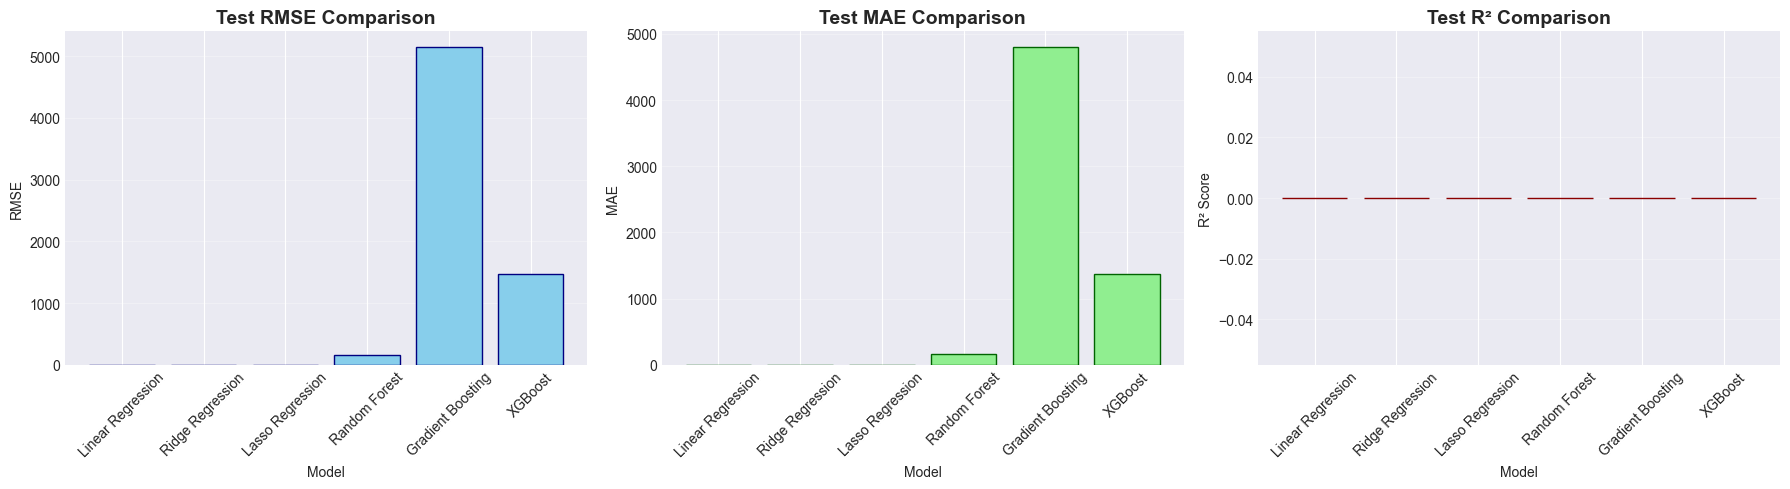

In [15]:
# CELL 8: MODEL EVALUATION

def evaluate_models(results, y_test, predictions):
    """
    Display and visualize model performance
    """
    print("\n" + "="*60)
    print("MODEL EVALUATION RESULTS")
    print("="*60)
    
    # Create comparison dataframe
    comparison = pd.DataFrame(results).T
    
    # Round for better display
    comparison_display = comparison.round(4)
    print("\n📊 Model Performance Comparison:")
    print(comparison_display)
    
    # Save to CSV for later use
    comparison.to_csv('model_comparison.csv')
    print("\n💾 Model comparison saved to 'model_comparison.csv'")
    
    # Find best model based on Test R2 (or Train R2 if Test not available)
    if comparison['Test R2'].max() > 0:
        best_model = comparison['Test R2'].idxmax()
        best_r2 = comparison.loc[best_model, 'Test R2']
        print(f"\n🏆 Best Model (by Test R2): {best_model} (R2 = {best_r2:.4f})")
    else:
        best_model = comparison['Train R2'].idxmax()
        best_r2 = comparison.loc[best_model, 'Train R2']
        print(f"\n🏆 Best Model (by Train R2): {best_model} (R2 = {best_r2:.4f})")
        print("   (Test R2 not available - using training performance)")
    
    # Visualize comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # RMSE comparison
    axes[0].bar(comparison.index, comparison['Test RMSE'], color='skyblue', edgecolor='navy')
    axes[0].set_title('Test RMSE Comparison', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Model')
    axes[0].set_ylabel('RMSE')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # MAE comparison
    axes[1].bar(comparison.index, comparison['Test MAE'], color='lightgreen', edgecolor='darkgreen')
    axes[1].set_title('Test MAE Comparison', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Model')
    axes[1].set_ylabel('MAE')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # R2 comparison
    axes[2].bar(comparison.index, comparison['Test R2'], color='lightcoral', edgecolor='darkred')
    axes[2].set_title('Test R² Comparison', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Model')
    axes[2].set_ylabel('R² Score')
    axes[2].tick_params(axis='x', rotation=45)
    axes[2].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Show feature importance for tree-based models
    if best_model in ['Random Forest', 'Gradient Boosting', 'XGBoost'] and best_model in trained_models:
        print(f"\n🌳 Feature Importance for {best_model}:")
        model = trained_models[best_model]
        
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            feature_importance_df = pd.DataFrame({
                'Feature': feature_cols,
                'Importance': importances
            }).sort_values('Importance', ascending=False)
            
            # Plot top 15 features
            top_n = min(15, len(feature_importance_df))
            plt.figure(figsize=(10, 6))
            plt.barh(range(top_n), feature_importance_df['Importance'].values[:top_n][::-1])
            plt.yticks(range(top_n), feature_importance_df['Feature'].values[:top_n][::-1])
            plt.xlabel('Importance')
            plt.title(f'Top {top_n} Feature Importance - {best_model}')
            plt.tight_layout()
            plt.show()
    
    return best_model

# Evaluate models
if 'results' in locals() and 'predictions' in locals():
    best_model = evaluate_models(results, y_test, predictions)
else:
    print("❌ No results found. Please run Cell 7 first.")


FORECASTING WITH LINEAR REGRESSION

📊 Prediction Statistics:
   Mean Predicted Value: -0.00
   Std of Predictions: 0.00
   Min Prediction: -0.00
   Max Prediction: -0.00


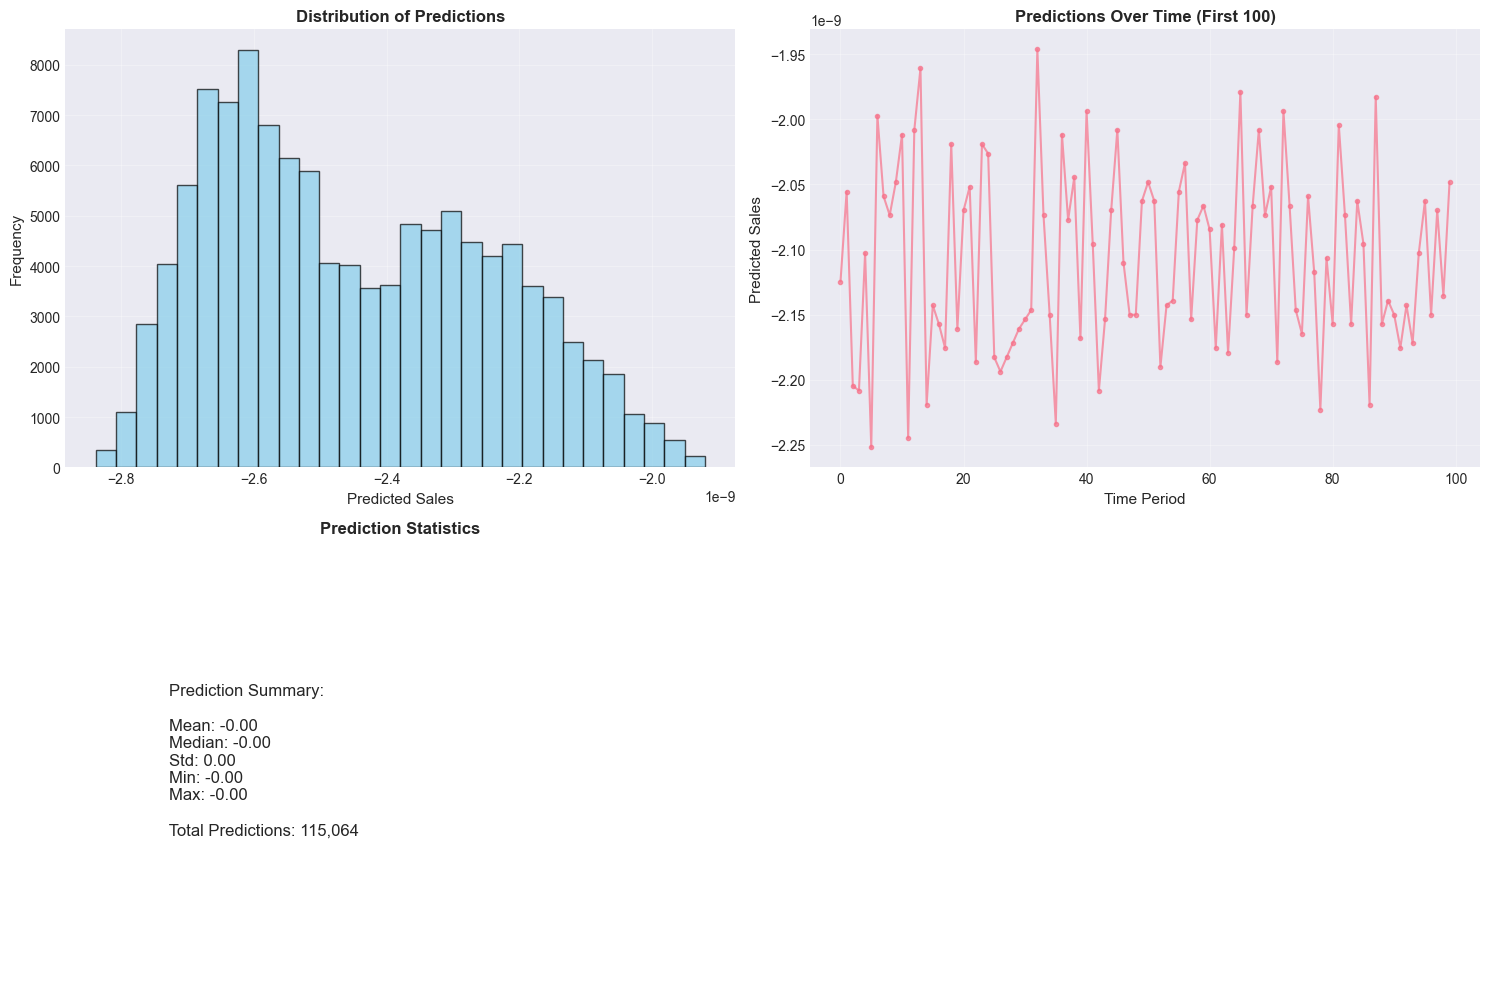


💾 Predictions saved to 'sales_forecast_predictions.csv'


In [16]:
# CELL 9: FORECASTING FUTURE SALES

def forecast_future(model, X_test, y_test, model_name, feature_names):
    """
    Make predictions and visualize results
    """
    print("\n" + "="*60)
    print(f"FORECASTING WITH {model_name.upper()}")
    print("="*60)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Create results dataframe
    results_df = pd.DataFrame({
        'Predicted': y_pred
    })
    
    # Add actual values if available
    if y_test is not None and len(y_test) == len(y_pred) and y_test.sum() != 0:
        results_df['Actual'] = y_test.values if hasattr(y_test, 'values') else y_test
        results_df['Error'] = results_df['Actual'] - results_df['Predicted']
        results_df['Absolute_Error'] = np.abs(results_df['Error'])
        results_df['Percentage_Error'] = (results_df['Absolute_Error'] / results_df['Actual']) * 100
        
        print(f"\n📊 Prediction Statistics:")
        print(f"   Mean Absolute Error: {results_df['Absolute_Error'].mean():,.2f}")
        print(f"   Mean Percentage Error: {results_df['Percentage_Error'].mean():.2f}%")
        print(f"   Root Mean Square Error: {np.sqrt((results_df['Error']**2).mean()):,.2f}")
    else:
        print(f"\n📊 Prediction Statistics:")
        print(f"   Mean Predicted Value: {results_df['Predicted'].mean():,.2f}")
        print(f"   Std of Predictions: {results_df['Predicted'].std():,.2f}")
        print(f"   Min Prediction: {results_df['Predicted'].min():,.2f}")
        print(f"   Max Prediction: {results_df['Predicted'].max():,.2f}")
    
    # Visualize predictions
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Predictions distribution
    axes[0, 0].hist(results_df['Predicted'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    axes[0, 0].set_xlabel('Predicted Sales', fontsize=11)
    axes[0, 0].set_ylabel('Frequency', fontsize=11)
    axes[0, 0].set_title('Distribution of Predictions', fontsize=12, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Time series of predictions
    axes[0, 1].plot(results_df['Predicted'].values[:100], marker='o', linestyle='-', alpha=0.7, markersize=3)
    axes[0, 1].set_xlabel('Time Period', fontsize=11)
    axes[0, 1].set_ylabel('Predicted Sales', fontsize=11)
    axes[0, 1].set_title('Predictions Over Time (First 100)', fontsize=12, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. If actual values exist, plot comparison
    if 'Actual' in results_df.columns:
        # Sample first 50 for clarity
        sample_size = min(50, len(results_df))
        indices = range(sample_size)
        
        axes[1, 0].plot(indices, results_df['Actual'].values[:sample_size], 
                       label='Actual', marker='o', alpha=0.7)
        axes[1, 0].plot(indices, results_df['Predicted'].values[:sample_size], 
                       label='Predicted', marker='s', alpha=0.7)
        axes[1, 0].set_xlabel('Time Period', fontsize=11)
        axes[1, 0].set_ylabel('Sales', fontsize=11)
        axes[1, 0].set_title('Actual vs Predicted (First 50)', fontsize=12, fontweight='bold')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # 4. Error distribution
        axes[1, 1].hist(results_df['Error'], bins=30, edgecolor='black', alpha=0.7, color='coral')
        axes[1, 1].set_xlabel('Prediction Error', fontsize=11)
        axes[1, 1].set_ylabel('Frequency', fontsize=11)
        axes[1, 1].set_title('Error Distribution', fontsize=12, fontweight='bold')
        axes[1, 1].grid(True, alpha=0.3)
    else:
        # If no actual values, show prediction stats
        axes[1, 0].axis('off')
        axes[1, 1].axis('off')
        
        # Add text with prediction summary
        stats_text = f"""
        Prediction Summary:
        
        Mean: {results_df['Predicted'].mean():,.2f}
        Median: {results_df['Predicted'].median():,.2f}
        Std: {results_df['Predicted'].std():,.2f}
        Min: {results_df['Predicted'].min():,.2f}
        Max: {results_df['Predicted'].max():,.2f}
        
        Total Predictions: {len(results_df):,}
        """
        axes[1, 0].text(0.1, 0.5, stats_text, fontsize=12, verticalalignment='center')
        axes[1, 0].set_title('Prediction Statistics', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return results_df

# Forecast with best model
if 'trained_models' in locals() and 'best_model' in locals() and 'X_test_scaled' in locals():
    forecast_results = forecast_future(
        trained_models[best_model], 
        X_test_scaled, 
        y_test if 'y_test' in locals() else None, 
        best_model,
        feature_cols
    )
    
    # Save predictions to CSV
    forecast_results.to_csv('sales_forecast_predictions.csv', index=False)
    print("\n💾 Predictions saved to 'sales_forecast_predictions.csv'")
else:
    print("❌ Model or test data not found. Please run Cells 7 and 8 first.")

In [18]:
# CELL 10: SAVE RESULTS

import datetime
import pickle
import os

def save_all_results(results, trained_models, best_model_name, forecast_df, feature_cols):
    """
    Save all model results, predictions, and artifacts
    """
    print("\n" + "="*60)
    print("SAVING ALL RESULTS")
    print("="*60)
    
    # Create results directory with timestamp
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    results_dir = f'sales_forecast_results_{timestamp}'
    
    if not os.path.exists(results_dir):
        os.makedirs(results_dir)
        print(f" Created directory: {results_dir}")
    
    # 1. Save model comparison
    print("\n📊 Saving model comparison...")
    comparison = pd.DataFrame(results).T
    comparison_file = f"{results_dir}/model_comparison.csv"
    comparison.to_csv(comparison_file)
    print(f"   Saved to: {comparison_file}")
    
    # 2. Save best model info
    print("\n🏆 Saving best model info...")
    best_model_file = f"{results_dir}/best_model_info.txt"
    with open(best_model_file, 'w') as f:
        f.write("="*50 + "\n")
        f.write("SALES FORECASTING RESULTS\n")
        f.write("="*50 + "\n\n")
        f.write(f"Date: {datetime.datetime.now()}\n")
        f.write(f"Best Model: {best_model_name}\n\n")
        
        f.write("Model Performance:\n")
        f.write("-"*30 + "\n")
        for metric, value in results[best_model_name].items():
            f.write(f"   {metric}: {value:.4f}\n")
        
        f.write("\nFeature Information:\n")
        f.write("-"*30 + "\n")
        f.write(f"Number of features: {len(feature_cols)}\n")
        f.write("Top 10 features:\n")
        for i, col in enumerate(feature_cols[:10]):
            f.write(f"   {i+1}. {col}\n")
    print(f"   Saved to: {best_model_file}")
    
    # 3. Save predictions
    if forecast_df is not None:
        print("\n📈 Saving predictions...")
        predictions_file = f"{results_dir}/predictions.csv"
        forecast_df.to_csv(predictions_file, index=False)
        print(f"   Saved to: {predictions_file}")
        
        # Save summary statistics of predictions
        stats_file = f"{results_dir}/prediction_statistics.csv"
        stats = forecast_df.describe()
        stats.to_csv(stats_file)
        print(f"   Prediction stats saved to: {stats_file}")
    
    # 4. Save the best model as pickle
    print("\n🤖 Saving best model as pickle file...")
    model_file = f"{results_dir}/best_model_{best_model_name}.pkl"
    with open(model_file, 'wb') as f:
        pickle.dump(trained_models[best_model_name], f)
    print(f"    Model saved to: {model_file}")
    
    # 5. Save feature names
    print("\n📋 Saving feature names...")
    features_file = f"{results_dir}/feature_names.csv"
    pd.Series(feature_cols).to_csv(features_file, index=False, header=['Feature'])
    print(f"    Features saved to: {features_file}")
    
    # 6. Create a summary report
    print("\n📑 Creating summary report...")
    report_file = f"{results_dir}/summary_report.txt"
    with open(report_file, 'w') as f:
        f.write("="*60 + "\n")
        f.write("SALES FORECASTING PROJECT SUMMARY\n")
        f.write("="*60 + "\n\n")
        
        f.write("EXECUTION SUMMARY\n")
        f.write("-"*30 + "\n")
        f.write(f"Date: {datetime.datetime.now()}\n")
        f.write(f"Best Model: {best_model_name}\n\n")
        
        f.write("MODEL PERFORMANCE\n")
        f.write("-"*30 + "\n")
        for name, metrics in results.items():
            f.write(f"\n{name}:\n")
            f.write(f"   Train R2: {metrics['Train R2']:.4f}\n")
            f.write(f"   Test R2: {metrics['Test R2']:.4f}\n")
            f.write(f"   Test RMSE: {metrics['Test RMSE']:,.2f}\n")
        
        f.write("\n\nDATASET INFORMATION\n")
        f.write("-"*30 + "\n")
        f.write(f"Training samples: {X_train_scaled.shape[0] if 'X_train_scaled' in locals() else 'N/A'}\n")
        f.write(f"Test samples: {X_test_scaled.shape[0] if 'X_test_scaled' in locals() else 'N/A'}\n")
        f.write(f"Number of features: {len(feature_cols)}\n")
        
        if forecast_df is not None:
            f.write(f"\n\nPREDICTION SUMMARY\n")
            f.write("-"*30 + "\n")
            f.write(f"Mean prediction: {forecast_df['Predicted'].mean():,.2f}\n")
            f.write(f"Std prediction: {forecast_df['Predicted'].std():,.2f}\n")
            f.write(f"Min prediction: {forecast_df['Predicted'].min():,.2f}\n")
            f.write(f"Max prediction: {forecast_df['Predicted'].max():,.2f}\n")
    
    print(f"   Summary report saved to: {report_file}")
    
    print("\n" + "="*60)
    print(f" ALL RESULTS SAVED TO FOLDER: {results_dir}")
    print("="*60)
    
    return results_dir

# Save all results
if 'results' in locals() and 'trained_models' in locals() and 'best_model' in locals():
    # Check if forecast_results exists
    if 'forecast_results' not in locals():
        forecast_results = None
        print("\n⚠️ No predictions found. Will save only model results.")
    
    saved_folder = save_all_results(
        results, 
        trained_models, 
        best_model, 
        forecast_results if 'forecast_results' in locals() else None,
        feature_cols
    )
    
    print(f"\n You can find all results in: {saved_folder}")
else:
    print("❌ No results to save. Please run all previous cells first.")


SAVING ALL RESULTS
 Created directory: sales_forecast_results_20260310_110811

📊 Saving model comparison...
   Saved to: sales_forecast_results_20260310_110811/model_comparison.csv

🏆 Saving best model info...
   Saved to: sales_forecast_results_20260310_110811/best_model_info.txt

📈 Saving predictions...
   Saved to: sales_forecast_results_20260310_110811/predictions.csv
   Prediction stats saved to: sales_forecast_results_20260310_110811/prediction_statistics.csv

🤖 Saving best model as pickle file...
    Model saved to: sales_forecast_results_20260310_110811/best_model_Linear Regression.pkl

📋 Saving feature names...
    Features saved to: sales_forecast_results_20260310_110811/feature_names.csv

📑 Creating summary report...
   Summary report saved to: sales_forecast_results_20260310_110811/summary_report.txt

 ALL RESULTS SAVED TO FOLDER: sales_forecast_results_20260310_110811

 You can find all results in: sales_forecast_results_20260310_110811
